In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

**Homework 2**

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [3]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [ ]:
df.head()

**Histogram: Fuel efficiency MPG**
**Does it have a long tail?**

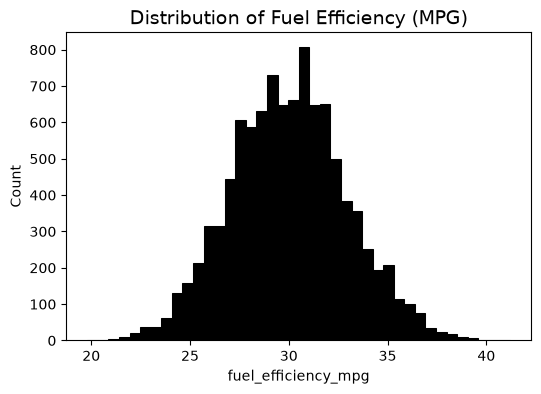

In [4]:
plt.figure(figsize=(6, 4))

sns.histplot(df.fuel_efficiency_mpg, bins=40, color='black', alpha=1)
plt.title('Distribution of Fuel Efficiency (MPG)', fontsize=14)

plt.show()

There is no long tail in the histogram; the distribution is close to normal.

**Using only the following columns**
**'engine_displacement',**
**'horsepower',**
**'vehicle_weight',**
**'model_year',**
**'fuel_efficiency_mpg'**

**Question1. Missing Values**

In [7]:
df = df[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year',
        'fuel_efficiency_mpg'
    ]
]

In [8]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

**Question 2. Median for horsepower**

In [6]:
df['horsepower'].median()

np.float64(254.0)

**Prepare and split de dataset**

In [18]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

**Reset the index**

In [19]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7


**Save fuel efficiency values**

In [ ]:

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values


In [21]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7


**Delete "fuel_efficiency_mpg" to avoid using fuel efficiency to predict fuel efficiency.**


In [22]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [23]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001


**Code from lessons for linear regression model (without regularization)**

In [ ]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

**Code from lessons for rmse**

In [25]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

**Question 3**

**Fill NAs in horsepower with 0**

In [ ]:
X_train = df_train.copy()
X_train['horsepower'] = X_train['horsepower'].fillna(0)
X_train = X_train.values

w_0, w = train_linear_regression(X_train, y_train)

X_val = df_val.copy()
X_val['horsepower'] = X_val['horsepower'].fillna(0)
X_val = X_val.values

y_pred = w_0 + X_val.dot(w)

score = rmse(y_val, y_pred)
print(round(score, 3))


2.205


**Fill NA's with the mean value using the training set only**

In [27]:
mean_hp = df_train['horsepower'].mean()

X_train = df_train.copy()
X_train['horsepower'] = X_train['horsepower'].fillna(mean_hp)
X_train = X_train.values

w_0, w = train_linear_regression(X_train, y_train)

X_val = df_val.copy()
X_val['horsepower'] = X_val['horsepower'].fillna(mean_hp)
X_val = X_val.values

y_pred = w_0 + X_val.dot(w)

score = rmse(y_val, y_pred)

print(round(score, 3))

2.202


**Question 4**

**Code from lessons for linear regression model (with regularization)**

In [28]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

**Fill NAs with 0**

In [29]:
X_train = df_train.copy()
X_train['horsepower'] = X_train['horsepower'].fillna(0)
X_train = X_train.values

X_val = df_val.copy()
X_val['horsepower'] = X_val['horsepower'].fillna(0)
X_val = X_val.values

**Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].**

In [32]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    y_pred = w_0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, round(score, 3))

0 2.205
0.01 2.206
0.1 2.224
1 2.349
5 2.409
10 2.419
100 2.429


**Question 5**

-We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
-Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
-For each seed, do the train/validation/test split with 60%/20%/20% distribution.
-Fill the missing values with 0 and train a model without regularization.
-For each seed, evaluate the model on the validation dataset and collect the RMSE scores.


In [33]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:

    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    X_train = df_train.drop('fuel_efficiency_mpg', axis=1).copy()
    X_train['horsepower'] = X_train['horsepower'].fillna(0)
    X_train = X_train.values

    X_val = df_val.drop('fuel_efficiency_mpg', axis=1).copy()
    X_val['horsepower'] = X_val['horsepower'].fillna(0)
    X_val = X_val.values

    w_0, w = train_linear_regression(X_train, y_train)

    y_pred = w_0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    scores.append(score)

-What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
-Round the result to 3 decimal digits (round(std, 3))

In [36]:
std = np.std(scores)
print(round(std, 3))

0.029


**Question 6**

-Split the dataset like previously, use seed 9.


In [37]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

-Combine train and validation datasets.


In [38]:
df_train_full = pd.concat([df_train, df_val])
df_train_full.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
3644,2320,246.0,4100,2014,32.5
9184,2230,252.0,4250,1998,33.2
520,2700,276.0,4490,2008,32.4
5685,2220,269.0,4060,2004,29.9
2401,2370,NaN,4690,1979,26.4


In [39]:
df_train_full = df_train_full.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train_full.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2320,246.0,4100,2014,32.5
1,2230,252.0,4250,1998,33.2
2,2700,276.0,4490,2008,32.4
3,2220,269.0,4060,2004,29.9
4,2370,NaN,4690,1979,26.4


In [40]:
y_train_full = df_train_full['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

del df_train_full['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

-Fill the missing values with 0 and train a model with r=0.001.


In [41]:
X_train_full = df_train_full.copy()
X_train_full['horsepower'] = X_train_full['horsepower'].fillna(0)
X_train_full = X_train_full.values

X_test = df_test.copy()
X_test['horsepower'] = X_test['horsepower'].fillna(0)
X_test = X_test.values

w_0, w = train_linear_regression_reg(X_train_full, y_train_full, r=0.001)
y_pred = w_0 + X_test.dot(w)

-What's the RMSE on the test dataset?

In [42]:
score = rmse(y_test, y_pred)
print(round(score,3))

2.236
